In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import math
import random

In [17]:
qc = QuantumCircuit(3)
qc.h(range(3))
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [18]:
# here i have used a random number instead of marking a specific number from 0 to 7 and observed the results.
key = random.randint(0, pow(2,3)-1)
keybin = format(key, f'0{3}b')

In [19]:
def oracle(qc, keystring):
    reversed_key = keybin[::-1]
    for i in range(3):
        if(reversed_key[i] == '0'):
            qc.x(i)
    controls = list(range(2))
    target = 2
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)
    for i in range(3):
        if(reversed_key[i] == '0'):
            qc.x(i)

In [20]:
def diffusion_oracle(qc, n):
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))

In [21]:
grov_iter = math.floor(math.pi/4 * math.sqrt(2**3))

for i in range(grov_iter):
    oracle(qc, keybin)
    diffusion_oracle(qc, 3)
qc.measure_all()

In [22]:
sim = AerSimulator()

qcc = transpile(qc, sim)
task = sim.run(qcc, shots = 2048)
res = task.result()
cnt = res.get_counts()
print(keybin)
print(cnt)

010
{'010': 1949, '001': 17, '110': 10, '101': 16, '111': 17, '000': 18, '100': 11, '011': 10}


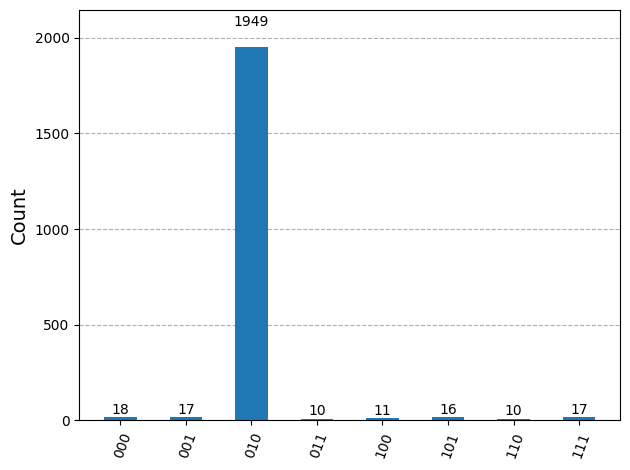

In [23]:
plot_histogram(cnt)